## BSGP 7030 assignment 5A -- python machine learning tutorial

#### 1.1 Installing SciPy libraries

#### 1.2 starting notebook and checking versions

In [3]:
## Python version
import sys
print('Python: {}'.format(sys.version))

## scipy
import scipy
print('scipy: {}'.format(scipy.__version__))

## numpy
import numpy
print('numpy: {}'.format(numpy.__version__))

## matplotlib
import matplotlib
print('matplotlib: {}'.format(matplotlib.__version__))

## pandas
import pandas
print('pandas: {}'.format(pandas.__version__))

## scikit-learn
import sklearn
print('sklearn: {}'.format(sklearn.__version__))

Python: 3.11.15 | packaged by conda-forge | (main, Jun 11 2026, 03:34:02) [GCC 14.3.0]
scipy: 1.17.1
numpy: 2.4.6
matplotlib: 3.11.1
pandas: 3.0.5
sklearn: 1.9.0


### 2 loading data

#### 2.1 importing libaries required for tutorial

In [6]:
## Load libraries that are used in this tutorial
from pandas import read_csv
import pandas as pd
from pandas.plotting import scatter_matrix
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

#### 2.2 Load Dataset

In [7]:
## reading using pandas (tutorial had it come from a URL, but I already saved it in my local directory for this assignment
iris = pd.read_csv('iris.csv')

### 3. Summarize the dataset

In [9]:
## printing the shape of iris.csv
iris.shape

(150, 5)

In [15]:
## reading the first 20 rows of observations
iris.head(20)

,sepal_length,sepal_width,petal_length,petal_width,name
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
5,5.4,3.9,1.7,0.4,setosa
6,4.6,3.4,1.4,0.3,setosa
7,5.0,3.4,1.5,0.2,setosa
8,4.4,2.9,1.4,0.2,setosa
9,4.9,3.1,1.5,0.1,setosa


In [11]:
## creating a statistical summary
iris.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [16]:
## looking at class distributions
iris.groupby('name').size()

name
setosa        50
versicolor    50
virginica     50
dtype: int64

### 4. Data visualizations

#### 4.1 univariative plots

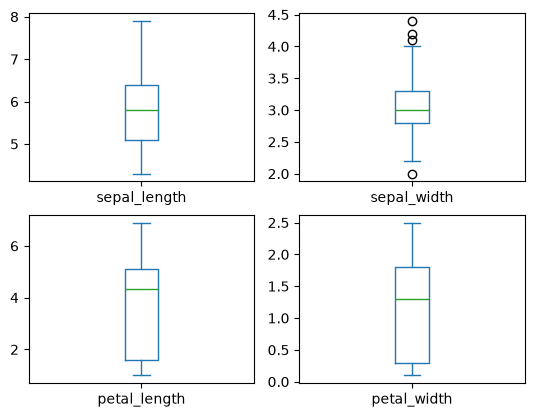

In [17]:
## creating a box and whisker plot
iris.plot(kind = 'box', subplots = True, layout = (2,2), sharex = False, sharey = False)
plt.show()

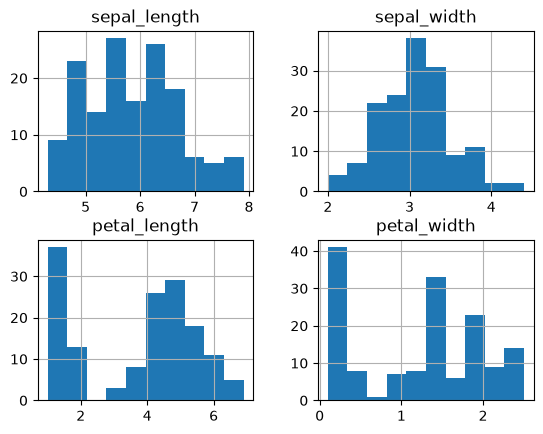

In [18]:
## creating a histogram of petal length and width
iris.hist()
plt.show()

#### 4.2 Multivariate Plots

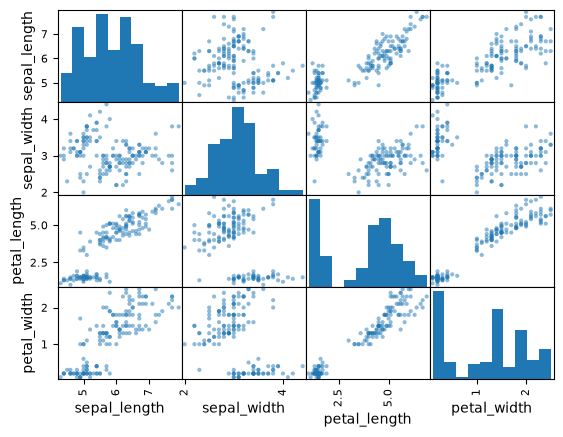

In [19]:
## scatter plot matrix
scatter_matrix(iris)
plt.show()

### 5. Evaluating some algorithms

#### 5.1 creating a valdiation dataset

In [21]:
## split-out validation dataset
array = iris.values
X = array[:, 0:4]
y = array[:, 4]
X_train, X_val, Y_train, Y_val = train_test_split(X, y, test_size = 0.2, random_state = 1)

#### 5.2 Test Harness using a stratified 10 fold CV for model accuracy assessment

#### 5.3 Building models

In [26]:
# Spot Check Algorithms
models = []
models.append(('LR', LogisticRegression(solver='lbfgs', max_iter=1000)))
models.append(('LDA', LinearDiscriminantAnalysis()))
models.append(('KNN', KNeighborsClassifier()))
models.append(('CART', DecisionTreeClassifier()))
models.append(('NB', GaussianNB()))
models.append(('SVM', SVC(gamma='auto')))

# evaluate each model in turn
results = []
names = []
for name, model in models:
    kfold = StratifiedKFold(n_splits=10, random_state=1, shuffle=True)
    cv_results = cross_val_score(model, X_train, Y_train, cv=kfold, scoring='accuracy')
    results.append(cv_results)
    names.append(name)
    print('%s: %f (%f)' % (name, cv_results.mean(), cv_results.std()))

LR: 0.966667 (0.040825)
LDA: 0.975000 (0.038188)
KNN: 0.958333 (0.041667)
CART: 0.950000 (0.055277)
NB: 0.950000 (0.055277)
SVM: 0.983333 (0.033333)


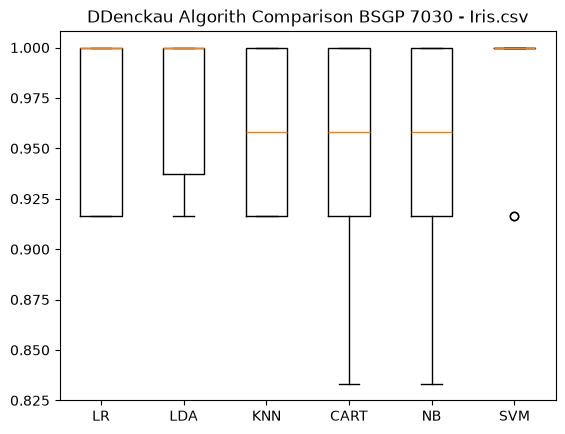

In [28]:
## comparing each algorithm
plt.boxplot(results, tick_labels = names)
plt.title('DDenckau Algorith Comparison BSGP 7030 - Iris.csv')
plt.show()

### Make Predictions

#### 6.1 Making predictions


In [29]:
## making predicitons on a validatation dataset
model = SVC(gamma = 'auto')
model.fit(X_train, Y_train)
preds = model.predict(X_val)

#### Evaluate predictions

In [37]:
## evaluating predictions
print("Accuracy Score:", accuracy_score(Y_val, preds))
print("Confusion matrix (true and false comparisons):", confusion_matrix(Y_val, preds))
print("Classification Report:")
print(classification_report(Y_val, preds))

Accuracy Score: 0.9666666666666667
Confusion matrix (true and false comparisons): [[11  0  0]
 [ 0 12  1]
 [ 0  0  6]]
Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        11
  versicolor       1.00      0.92      0.96        13
   virginica       0.86      1.00      0.92         6

    accuracy                           0.97        30
   macro avg       0.95      0.97      0.96        30
weighted avg       0.97      0.97      0.97        30

